# Step 10 — Solutions Embedding and Recommendations

**Objective:** Evaluate adaptation options within the risk assessment framework.

**Options:**
1. Grid hardening (undergrounding transmission)
2. Distributed Energy Resources (DERs) and microgrids
3. Demand response
4. Policy recommendations (performance-based regulation)

In [1]:
import sys, pathlib
sys.path.insert(0, str(pathlib.Path.cwd().parent))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from config.settings import PROCESSED


## 10.1 Grid hardening: undergrounding cost-benefit

In [2]:
# Cost assumptions (literature)
UNDERGROUND_LOW  = 1_000_000  # USD/mile
UNDERGROUND_HIGH = 3_000_000  # USD/mile
ANNUAL_DAMAGE_PER_MILE = 50_000  # USD — from SAIDI/SAIFI cost literature

tx_km_at_risk = 5_000  # km — replace with actual HIFLD measurement
miles = tx_km_at_risk * 0.621
cost_low  = miles * UNDERGROUND_LOW
cost_high = miles * UNDERGROUND_HIGH
savings   = miles * ANNUAL_DAMAGE_PER_MILE
print(f'Miles at risk (placeholder): {miles:,.0f}')
print(f'Undergrounding cost: ${cost_low/1e9:.1f}B - ${cost_high/1e9:.1f}B')
print(f'Annual avoided damage: ${savings/1e6:.0f}M')
print(f'Simple payback: {cost_low/savings:.0f} - {cost_high/savings:.0f} years')


Miles at risk (placeholder): 3,105
Undergrounding cost: $3.1B - $9.3B
Annual avoided damage: $155M
Simple payback: 20 - 60 years


## 10.2 DERs / microgrids: priority county identification

In [3]:
# Priority criteria:
# 1. Top-quartile LOCA2 heat exposure (WSDI_delta)
# 2. Top-quartile EJ burden
# 3. Low existing distributed generation penetration (EIA-861 data needed)

loca2_path = PROCESSED['loca2_ercot']
ej_path    = PROCESSED['ejscreen_county']

if loca2_path.exists():
    loca2 = pd.read_csv(loca2_path)
    mid = loca2[(loca2['scenario'] == 'ssp585') & (loca2['period_label'] == 'mid')].copy()
    if 'WSDI_delta' in mid.columns:
        mid['high_heat'] = mid['WSDI_delta'] >= mid['WSDI_delta'].quantile(0.75)
        print(f'High-heat counties (top quartile WSDI change): {mid["high_heat"].sum()}')
    print('(Merge with EJScreen for double-exposure DER priority list)')
else:
    print('LOCA2 projections not yet built.')


High-heat counties (top quartile WSDI change): 133
(Merge with EJScreen for double-exposure DER priority list)


## 10.3 Demand response: MW reduction vs. temperature

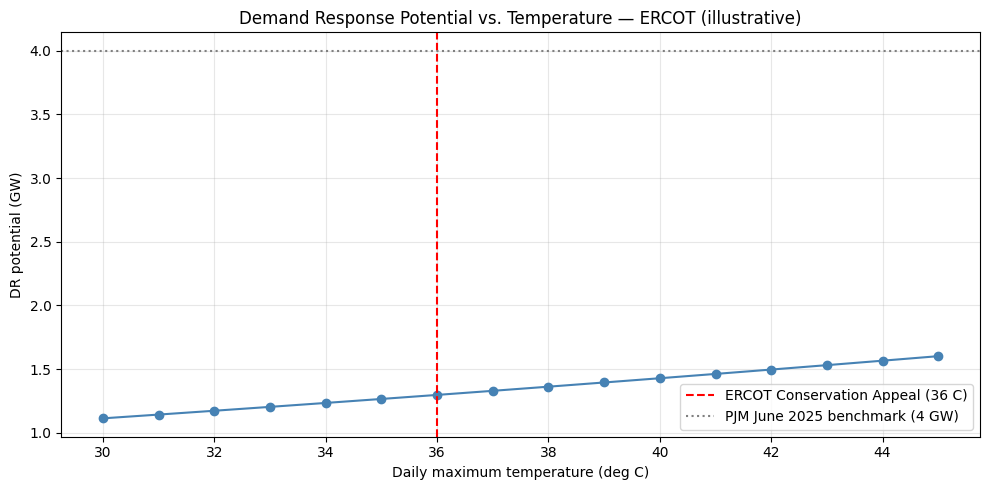

DR potential at 42 C: 1.5 GW


In [4]:
coef_tmax  = 800   # MW per deg C — replace with fitted value from NB06
coef_tmax2 = 10
COOLING_FRACTION = 0.35
DR_EFFICIENCY    = 0.06   # 6% load reduction per deg C thermostat adjustment
BASE_LOAD        = 20_000

temps = np.arange(30, 46, 1)
loads = BASE_LOAD + coef_tmax * temps + coef_tmax2 * temps**2
dr_mw = loads * COOLING_FRACTION * DR_EFFICIENCY

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(temps, dr_mw / 1000, marker='o', color='steelblue')
ax.axvline(36, color='red', linestyle='--', label='ERCOT Conservation Appeal (36 C)')
ax.axhline(4.0, color='gray', linestyle=':', label='PJM June 2025 benchmark (4 GW)')
ax.set_xlabel('Daily maximum temperature (deg C)')
ax.set_ylabel('DR potential (GW)')
ax.set_title('Demand Response Potential vs. Temperature — ERCOT (illustrative)')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('../data/processed/demand_response_curve.png', dpi=150)
plt.show()

print(f'DR potential at 42 C: {(BASE_LOAD + coef_tmax*42 + coef_tmax2*42**2)*COOLING_FRACTION*DR_EFFICIENCY/1000:.1f} GW')


## 10.4 Policy recommendations summary

In [5]:
recs = pd.DataFrame([
    {'Category': 'Grid hardening',
     'Action': 'Underground top-10% at-risk transmission (high heat + asset density)',
     'Success metric': 'SAIDI reduction during extreme events',
     'Cost (est.)': '$3-9B ERCOT',
     'Timeline': '2030-2040'},
    {'Category': 'DERs / microgrids',
     'Action': '5 GW distributed solar + 2-hr storage in high-EJ + high-heat counties',
     'Success metric': 'Customer-hours avoided during grid emergencies',
     'Cost (est.)': '$8-12B',
     'Timeline': '2027-2035'},
    {'Category': 'Demand response',
     'Action': 'Expand automated DR to 4 GW dispatchable in ERCOT by 2030',
     'Success metric': 'MW dispatched per Conservation Appeal event',
     'Cost (est.)': '$0.5-1B',
     'Timeline': '2025-2030'},
    {'Category': 'Regulatory reform',
     'Action': 'Adopt CMIP6 SSP5-8.5 as planning baseline; tie utility ROE to extreme-event SAIDI/SAIFI',
     'Success metric': 'Adoption in next IRP cycle; reduction in extreme-event outage hours',
     'Cost (est.)': 'Administrative only',
     'Timeline': '2025-2027'},
])
print(recs.to_string(index=False))
recs.to_csv('../data/processed/policy_recommendations.csv', index=False)
print('\nSaved policy_recommendations.csv')


         Category                                                                                  Action                                                      Success metric         Cost (est.)  Timeline
   Grid hardening                    Underground top-10% at-risk transmission (high heat + asset density)                               SAIDI reduction during extreme events         $3-9B ERCOT 2030-2040
DERs / microgrids                   5 GW distributed solar + 2-hr storage in high-EJ + high-heat counties                      Customer-hours avoided during grid emergencies              $8-12B 2027-2035
  Demand response                               Expand automated DR to 4 GW dispatchable in ERCOT by 2030                         MW dispatched per Conservation Appeal event             $0.5-1B 2025-2030
Regulatory reform Adopt CMIP6 SSP5-8.5 as planning baseline; tie utility ROE to extreme-event SAIDI/SAIFI Adoption in next IRP cycle; reduction in extreme-event outage hours Administra